# State and Process Tomography Lab
In this lab we perform various state and process tomography experiments. The experimental set-up is as follows:
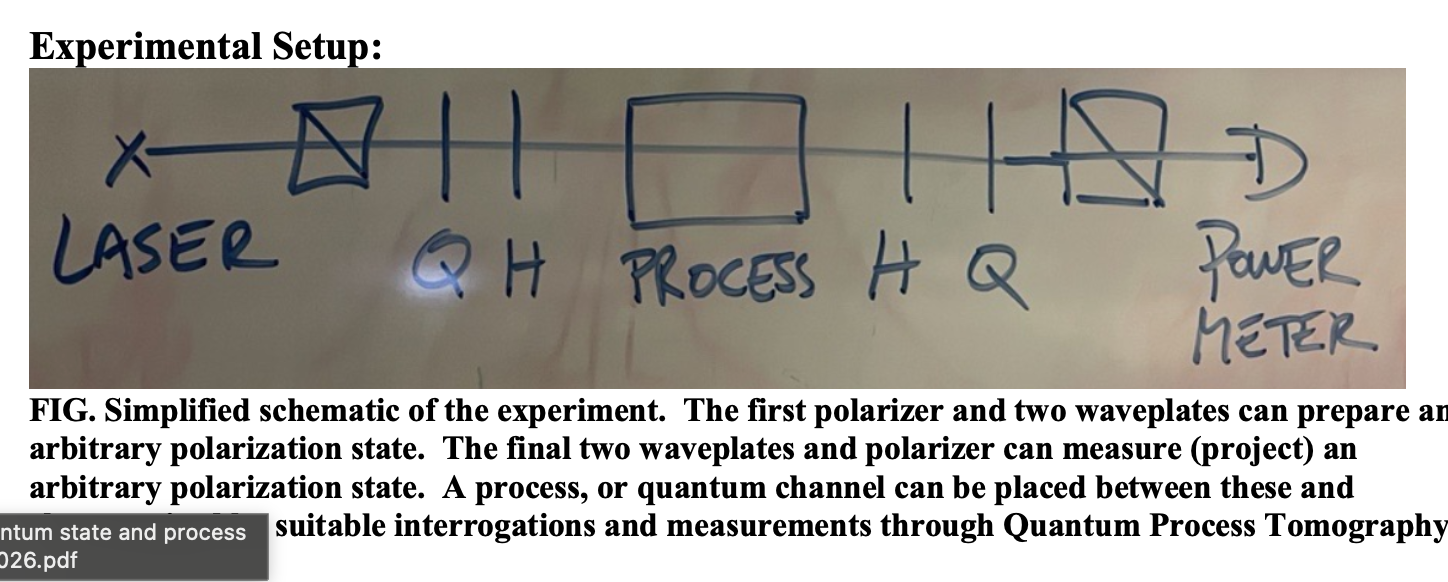

Our light source is an thorlabs laser diode emiting at 808nm. This then goes through a PBS to only allow H polarized light through (this is our initialization stage that prepares H polarized light). Then we have a quarter waveplate and a half waveplate which we use to manipulate H. This is our state preparation stage allowing us to prepare arbitrary states. Then we have a slot to add various optical elements (waveplate, beam splitter, etc.) to act as our process stage. These elements effectively implement a quantum channel. After this we have anote half waveplate and quarter waveplate followed by another PBS. This is our measurement stage. By tunning the waveplate accordingly we can measure what the projection of the state coming out of the processing stage onto arbitrary states. The way the measuring stage works is by mapping the state we want to measure to H, which the PBS let's shine through so we are only measuring the power contribution of the state we want to power. 

# Callibration Process

Our first task in this lab is to callibrate and characterize our set-up so that we know the parameters for our waveplate we need to use to prepare and measure our basis states so that in following experiments we can take measurements over a tomographically complete set of states. 


Our first step is to find the zero of our quarter waveplates. To do this we start with only the PBS's and our first QWP. We adjust the angle of the QWP and find the angle that gives us the maximum power. Each QWP has 4 zeros so we test each one to find which will give us the highest measured power. 

QWP1 characterization:

| Power (mW) | Angle (deg) |
| --- | --- |
| 2.321 | -4 |
| 2.327 | 270 |
| 2.317 | 180 |
| 2.328 | 90 |

so our first QWP's zero is 90deg

We zero QWP1 and repeat this procedure for QWP2

QWP2 characterization:

| Power (mW) | Angle (deg) |
| --- | --- |
| 2.319 | 268 |
| 2.319 | 178 |
| 2.315 | 88 |
| 2.315 | -4 |

So our 2nd QWP's zero is 268deg. 

We repeat this process by adding HWP1 and HWP2 to characterize them

HWP1 characterization:

| Power (mW) | Angle (deg) |
| --- | --- |
| 2.265 | -2 |
| 2.297 | 88 |
| 2.278 | 178 |
| 2.240 | 268 |

HWP2 characterization:

| Power (mW) | Angle (deg) |
| --- | --- |
| 2.283 | 268 |
| 2.288 | -2 |
| 2.288 | 178 |
| 2.285 | 178 |

so HWP1 and HWP2 have their zero we will use at 88deg. 

Using this then, we can find the angles we need to use to prepare and measure each possible state. 

The reported uncertainty for all our our measurements here is 0.0005mW and +-1 degrees

In [1]:
def prep(qwp_zero, hwp_zero):
    Hqwp = (qwp_zero) % 360
    Hhwp = (hwp_zero) % 360
    Vqwp = (qwp_zero) % 360
    Vhwp = (hwp_zero + 45) % 360
    Dqwp = (qwp_zero) % 360
    Dhwp = (hwp_zero + 22.5) % 360
    Rqwp = (qwp_zero-45) % 360
    Rhwp = (hwp_zero) % 360
    print(f"Preparing H: \n QWP: {Hqwp} \n HWP: {Hhwp} \n Preparing V: \n QWP: {Vqwp} \n HWP: {Vhwp} \n Preparing D: \n QWP: {Dqwp} \n HWP: {Dhwp} \n Preparing R: \n QWP: {Rqwp} \n HWP: {Rhwp}")

prep(90,88)

def measure(hwp_zero, qwp_zero):
    Hhwp = (hwp_zero) % 360
    Hqwp = (qwp_zero) % 360
    Vhwp = (hwp_zero + 45) % 360
    Vqwp = (qwp_zero) % 360
    Dhwp = (hwp_zero + 22.5) % 360
    Dqwp = (qwp_zero) % 360
    Rhwp = (hwp_zero) % 360
    Rqwp = (qwp_zero+45) % 360
    print(f"Measuring H: \n HWP: {Hhwp} \n QWP: {Hqwp} \n Measuring V: \n HWP: {Vhwp} \n QWP: {Vqwp} \n Measuring D: \n HWP: {Dhwp} \n QWP: {Dqwp} \n Measuring R: \n HWP: {Rhwp} \n QWP: {Rqwp}")

measure(88,268)

Preparing H: 
 QWP: 90 
 HWP: 88 
 Preparing V: 
 QWP: 90 
 HWP: 133 
 Preparing D: 
 QWP: 90 
 HWP: 110.5 
 Preparing R: 
 QWP: 45 
 HWP: 88
Measuring H: 
 HWP: 88 
 QWP: 268 
 Measuring V: 
 HWP: 133 
 QWP: 268 
 Measuring D: 
 HWP: 110.5 
 QWP: 268 
 Measuring R: 
 HWP: 88 
 QWP: 313


To make sure our settings for each state is correct, we prepare each and measure each state to make sure that we get power measurements near our base power of 2.288mW when all our waveplates are set to 0. 

prep H measure H

2.288mW

prev V measure V

2.272mW

Prep D measure D

2.276mW

prep R measure R

2.284


the uncertainty in all these measurements is 0.0005mW



Now we move on to experiment #2 and #3. These are our state tomography experiments. For experiment 2, we will prepare a state (we prepare H and R), perform a set of tomorgraphically complete measurements (HVDR basis chosen) for each of these state using our waveplate settings we found above. With these measurement we will then be able to use our state reconstruction code to recover the state we had.

Prep H:
| Meas. Basis | Power      |
|-------|------------|
| H     | 2.276 mW   |
| V     | 5.39 µW    |
| D     | 1.19 mW    |
| R     | 1.094 mW   |

Prep R:

| Meas. Basis | Power      |
|-------|------------|
| H     | 1.131 mW   |
| V     | 1.185 mW    |
| D     | 1.150 mW    |
| R     | 2.276 mW   |
| A | 1.087 mW|
| L | 2.85µW|

For the R state, we also measure A and L. These won't be inputs to our reconstruction code, but we will use this to see if our reconstructed matrix gives us appropriate predictions for measuring A and L. 

For Experiment 3, we add a polarizing beam displacer to effectively prepare a mixed state. We make sure that we see two beams coming out of the displacer and that both beams hit the power meter to avoid loss. We prepare the R state and then make our measurement. What we would expect is to measure a power equal to half our maximum power for each state since we have a maximally mixed state coming out of the beam displacer. 

Prep R (mixed):

| Meas. Basis | Power    |
|-------------|----------|
| H           | 1.081 mW |
| V           | 1.15 mW  |
| D           | 1.113 mW |
| R           | 1.129 mW |

For all measurements in mW our uncertainty is 0.0005mW and for uncertainty of measurements in µW we have 0.0005µW of uncertainty. 

For experiment 3, 4 and 5 we are doing process tomography experiments. For these, we must take a measurement for each preparation/measurement pair (16 total measurements). 

For all measurements in mW our uncertainty is 0.0005mW unless otherwise stated. 

First we take measurement for the identity channel (i.e. no optical elements added in the channel slot). 
| Prep | Measure | Measure (mW)|
|----|-----|---------|
| H  | H   | 2.283   |
| H  | V   | 0.01213 +- 0.000005 |
| H  | D   | 1.105   |
| H  | R   | 1.037   |
| V  | H   | 0.002682+-0.0000005|
| V  | V   | 2.267   |
| V  | D   | 1.167   |
| V  | R   | 1.086   |
| D  | H   | 1.180   |
| D  | V   | 1.105   |
| D  | D   | 2.276   |
| D  | R   | 1.107   |
| R  | H   | 1.127   |
| R  | V   | 1.117   |
| R  | D   | 1.211   |
| R  | R   | 2.285   |


Next we take measurements for the Hadamard as a channel. We implement this using a HWP set to it's 0 + 22.5. For us this was 76+22.5 = 98.5deg

| Prep | Measure | Measure (mW) |
|------|---------|--------------|
| H    | H       | 1.035        |
| H    | V       | 1.257        |
| H    | D       | 2.270        |
| H    | R       | 1.205        |
| V    | H       | 1.291        |
| V    | V       | 1.011        |
| V    | D       | 0.008440+-0.0000005    |
| V    | R       | 1.147        |
| D    | H       | 2.257        |
| D    | V       | 7.10         |
| D    | D       | 1.274        |
| D    | R       | 1.183        |
| R    | H       | 1.209        |
| R    | V       | 1.098        |
| R    | D       | 1.107        |
| R    | R       | 0.002214+-0.0000005     |


Our next channel is the "bad halwwaveplate". This HWP has a retardance that isn't actually Pi, so by reconstructing it's process matrix our goal is to figure out what it's retardance actually is. 

| Prep | Measure | Measure (mW) |
|------|---------|--------------|
| H    | H       | 2.260        |
| H    | V       | 0.02547+-0.000005     |
| H    | D       | 1.380        |
| H    | R       | 1.198        |
| V    | H       | 0.02397+-0.000005   |
| V    | V       | 2.246        |
| V    | D       | 0.907        |
| V    | R       | 1.194        |
| D    | H       | 1.308        |
| D    | V       | 0.966        |
| D    | D       | 0.0958 +-0.00005      |
| D    | R       | 0.701        |
| R    | H       | 1.041        |
| R    | V       | 1.261        |
| R    | D       | 1.517        |
| R    | R       | 0.092  +- 0.0005      |


Next up is experiment 5 where we implement a non-unitary trace preserving channel. This is done by using the calcite beam displacer.  It's important that we make sure the beam displacer has both beams coming out it, otherwise this will affect our measurements since we would be missing half the light. 

| In | Out | Measure (mW) |
|----|-----|--------------|
| H  | H   | 2.280        |
| H  | V   | 0.01147+- 0.000005  |
| H  | D   | 1.237        |
| H  | R   | 1.131        |
| V  | H   | 0.01126  +-0.000005    |
| V  | V   | 2.229        |
| V  | D   | 1.035        |
| V  | R   | 1.155        |
| D  | H   | 1.239        |
| D  | V   | 1.029        |
| D  | D   | 1.137        |
| D  | R   | 1.142        |
| R  | H   | 1.113        |
| R  | V   | 1.158        |
| R  | D   | 1.128        |
| R  | R   | 1.142        |


Lastly, for experiment #6 we implement a non trace preserving using some microscope slides to act as a partial polarizer. When light hit's the interface, it will reflect and transmit different amounts of P and S polarized light. 

| In | Out | Measure (mW) |
|----|-----|---------|
| H  | H   | 1.574   |
| H  | V   | 0.004777 +- 0.0000005 |
| H  | D   | 0.767   |
| H  | R   | 0.724   |
| V  | H   | 0.001293+-0.0000005 |
| V  | V   | 1.756   |
| V  | D   | 0.899   |
| V  | R   | 0.861   |
| D  | H   | 0.786   |
| D  | V   | 0.881   |
| D  | D   | 1.667   |
| D  | R   | 0.805   |
| R  | H   | 0.774   |
| R  | V   | 0.873   |
| R  | D   | 0.892   |
| R  | R   | 1.688   |